<div style="background:linear-gradient(135deg,#001F3F 0%,#0093D5 100%);padding:40px 32px;border-left:6px solid #EE3A43;">
<h1 style="color:#fff;font-family:Arial,sans-serif;font-size:28px;margin:0 0 8px;">06 — Churn Interpretation (SHAP)</h1>
<h2 style="color:rgba(255,255,255,.75);font-family:Arial,sans-serif;font-size:16px;font-weight:400;margin:0 0 20px;">SpiriCom · NOC Intelligence Platform · Huawei Technologies Tunisia</h2>
<div style="display:flex;gap:32px;flex-wrap:wrap;">
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Models</strong><br/>LR (primary) · RF · XGBoost</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Method</strong><br/>SHAP (SHapley Additive exPlanations)</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Outputs</strong><br/>Global importance · Force plots · Business insights</div>
</div></div>

In [2]:
# ═══════════════════════════════════════════════════════════════════════
# 0.  IMPORTS, PATHS & HUAWEI STYLE
# ═══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy  as np
import json, warnings, joblib
from pathlib  import Path
from datetime import datetime

import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import matplotlib.colors  as mcolors
import seaborn as sns
import shap

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ──────────────────────────────────────────────────────────────
PROC_DIR  = Path('data/processed')
FIG_DIR   = Path('data/outputs/figures')
OUT_DIR   = Path('data/outputs')
MODEL_DIR = Path('models')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Huawei Brand Palette ───────────────────────────────────────────────
HW = dict(
    blue='#0093D5', red='#EE3A43', navy='#001F3F', cyan='#00C3FF',
    green='#22C55E', amber='#F59E0B', purple='#8B5CF6', orange='#F97316',
    muted='#6B7280',
)

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'white',
    'axes.edgecolor':'#E5E7EB', 'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'axes.grid.axis':'y', 'grid.color':'#F3F4F6',
    'axes.labelcolor':HW['navy'], 'axes.labelweight':'bold',
    'axes.titlesize':13, 'axes.titleweight':'bold', 'axes.titlecolor':HW['navy'],
    'xtick.color':HW['muted'], 'ytick.color':HW['muted'],
    'legend.fontsize':9, 'font.family':'DejaVu Sans',
    'figure.dpi':120, 'savefig.dpi':300,
    'savefig.bbox':'tight', 'savefig.facecolor':'white',
})

def add_watermark(fig, text='SpiriCom · Huawei Technologies Tunisia'):
    fig.text(0.99, 0.01, text, ha='right', va='bottom',
             fontsize=7, color=HW['muted'], style='italic',
             transform=fig.transFigure)

def save_fig(name):
    path = FIG_DIR / f'{name}.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'  Saved: {path}')

print('✅ Setup complete')

✅ Setup complete


c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 📊 Section 1 — Load Models & Data

In [3]:
# ── 1.1  Load feature matrix ─────────────────────────────────────────
feat = pd.read_parquet(PROC_DIR / 'churn_features.parquet')
feat.columns = feat.columns.str.lower()

# Feature sets — must match NB05
LEAKAGE       = {'c1_low_usage', 'c2_low_dur', 'msisdn', 'churn'}
CRITERION_COLS= {'total_traffic', 'duration'}

FEATURE_COLS      = [c for c in feat.columns if c not in LEAKAGE]
FEATURE_COLS_TREE = [c for c in FEATURE_COLS if c not in CRITERION_COLS]

X_all    = feat[FEATURE_COLS].values.astype(np.float32)
X_all_tree = feat[FEATURE_COLS_TREE].values.astype(np.float32)
y_all    = feat['churn'].values.astype(int)

print(f'Feature matrix  : {X_all.shape[0]:,} rows')
print(f'LR features     : {len(FEATURE_COLS)}  {FEATURE_COLS}')
print(f'Tree features   : {len(FEATURE_COLS_TREE)}  {FEATURE_COLS_TREE}')
print(f'Churn rate      : {y_all.mean()*100:.1f}%')

Feature matrix  : 4,896 rows
LR features     : 24  ['avg_packet_loss', 'avg_latency_ms', 'client_rtt_ms', 'voip_quality', 'session_active_rate', 'ratio_5g', 'total_traffic', 'traffic_5g', 'duration', 'nightly_ratio', 'gaming_ratio', 'social_ratio', 'traffic_diversity', 'brand_encoded', 'brand_freq', 'brand_churn_rate', 'generation_numeric', 'is_5g_capable', 'days_since_last_activity', 'activity_recency_score', 'province_encoded', 'province_freq', 'province_churn_rate', 'congestion_level']
Tree features   : 22  ['avg_packet_loss', 'avg_latency_ms', 'client_rtt_ms', 'voip_quality', 'session_active_rate', 'ratio_5g', 'traffic_5g', 'nightly_ratio', 'gaming_ratio', 'social_ratio', 'traffic_diversity', 'brand_encoded', 'brand_freq', 'brand_churn_rate', 'generation_numeric', 'is_5g_capable', 'days_since_last_activity', 'activity_recency_score', 'province_encoded', 'province_freq', 'province_churn_rate', 'congestion_level']
Churn rate      : 36.2%


In [4]:
# ── 1.2  Load models & scalers ───────────────────────────────────────
lr      = joblib.load(MODEL_DIR / 'churn_lr.pkl')
rf      = joblib.load(MODEL_DIR / 'churn_rf.pkl')
xgb_clf = joblib.load(MODEL_DIR / 'churn_xgb.pkl')
scaler  = joblib.load(MODEL_DIR / 'churn_scaler.pkl')

# Load tree scaler if exists, otherwise fit fresh
scaler_tree_path = MODEL_DIR / 'churn_scaler_tree.pkl'
if scaler_tree_path.exists():
    scaler_tree = joblib.load(scaler_tree_path)
else:
    scaler_tree = StandardScaler()
    split_idx   = int(len(feat) * 0.80)
    scaler_tree.fit(X_all_tree[:split_idx])
    joblib.dump(scaler_tree, scaler_tree_path)
    print('scaler_tree fitted and saved')

X_all_sc      = scaler.transform(X_all)
X_all_tree_sc = scaler_tree.transform(X_all_tree)

print('Models loaded:')
print(f'  LR  : {type(lr).__name__}')
print(f'  RF  : {type(rf).__name__}  (n_estimators={rf.n_estimators})')
print(f'  XGB : {type(xgb_clf).__name__}')

Models loaded:
  LR  : LogisticRegression
  RF  : RandomForestClassifier  (n_estimators=300)
  XGB : XGBClassifier


---
## 🔍 Section 2 — SHAP: Logistic Regression (Primary Model)
SHAP LinearExplainer for LR. Explains global and local feature contributions.

In [5]:
# ── 2.1  SHAP LinearExplainer for LR ─────────────────────────────────
print('Computing SHAP values for Logistic Regression...')
explainer_lr   = shap.LinearExplainer(lr, X_all_sc,
                                       feature_perturbation='correlation_dependent')
shap_values_lr = explainer_lr.shap_values(X_all_sc)

print(f'SHAP values shape : {shap_values_lr.shape}')
print(f'Features          : {len(FEATURE_COLS)}')
print('✅ LR SHAP values computed')

Computing SHAP values for Logistic Regression...


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms: 100%|██████████| 1000/1000 [00:02<00:00, 371.60it/s]

SHAP values shape : (4896, 24)
Features          : 24
✅ LR SHAP values computed


  Saved: data\outputs\figures\fig06_A1_shap_lr_summary.png


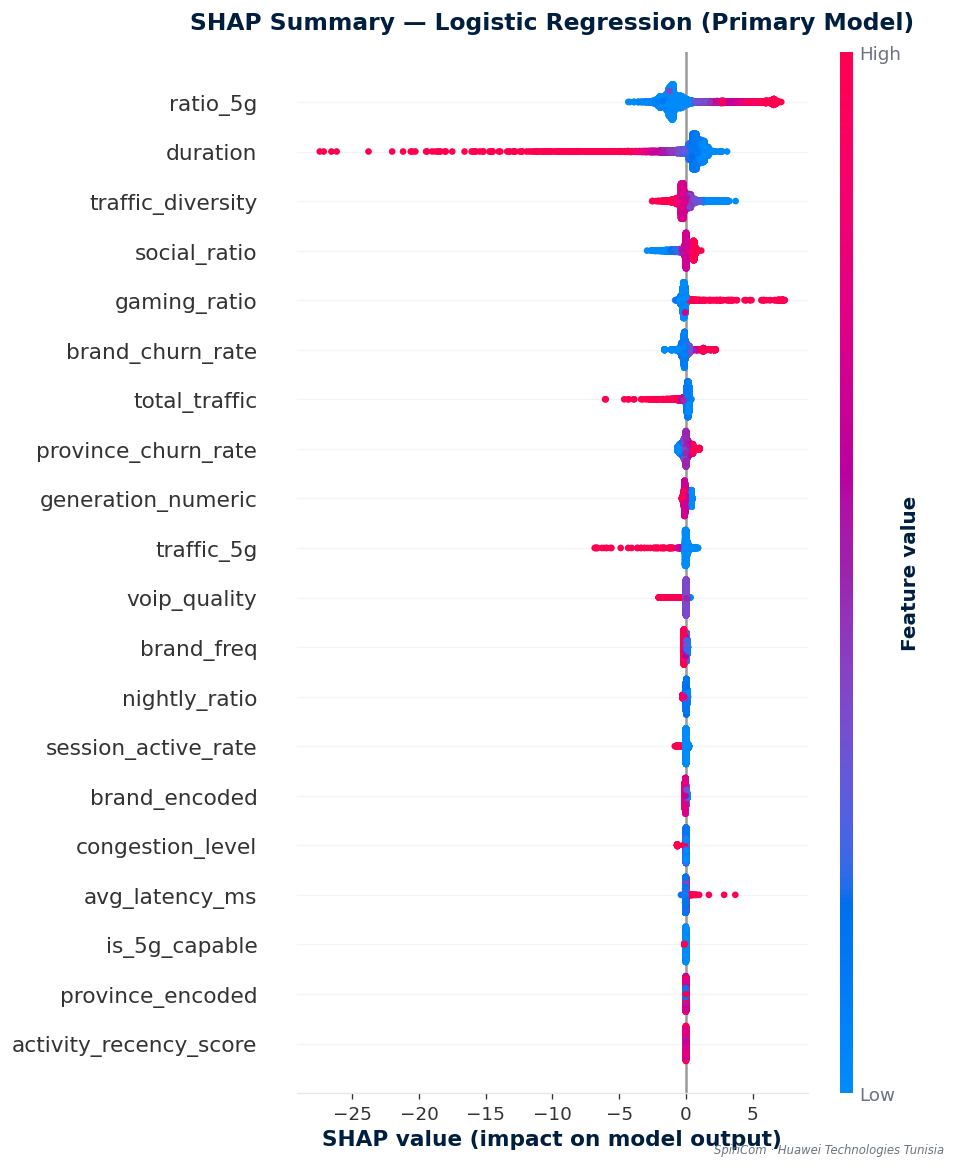

In [6]:
# ── 2.2  LR SHAP — Global summary plot (beeswarm) ────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    shap_values_lr,
    X_all_sc,
    feature_names = FEATURE_COLS,
    plot_type     = 'dot',
    max_display   = 20,
    show          = False,
    color_bar     = True,
)
plt.title('SHAP Summary — Logistic Regression (Primary Model)',
          fontsize=14, fontweight='bold', color=HW['navy'], pad=14)
add_watermark(fig)
save_fig('fig06_A1_shap_lr_summary')
plt.show()

  Saved: data\outputs\figures\fig06_A2_shap_lr_bar.png


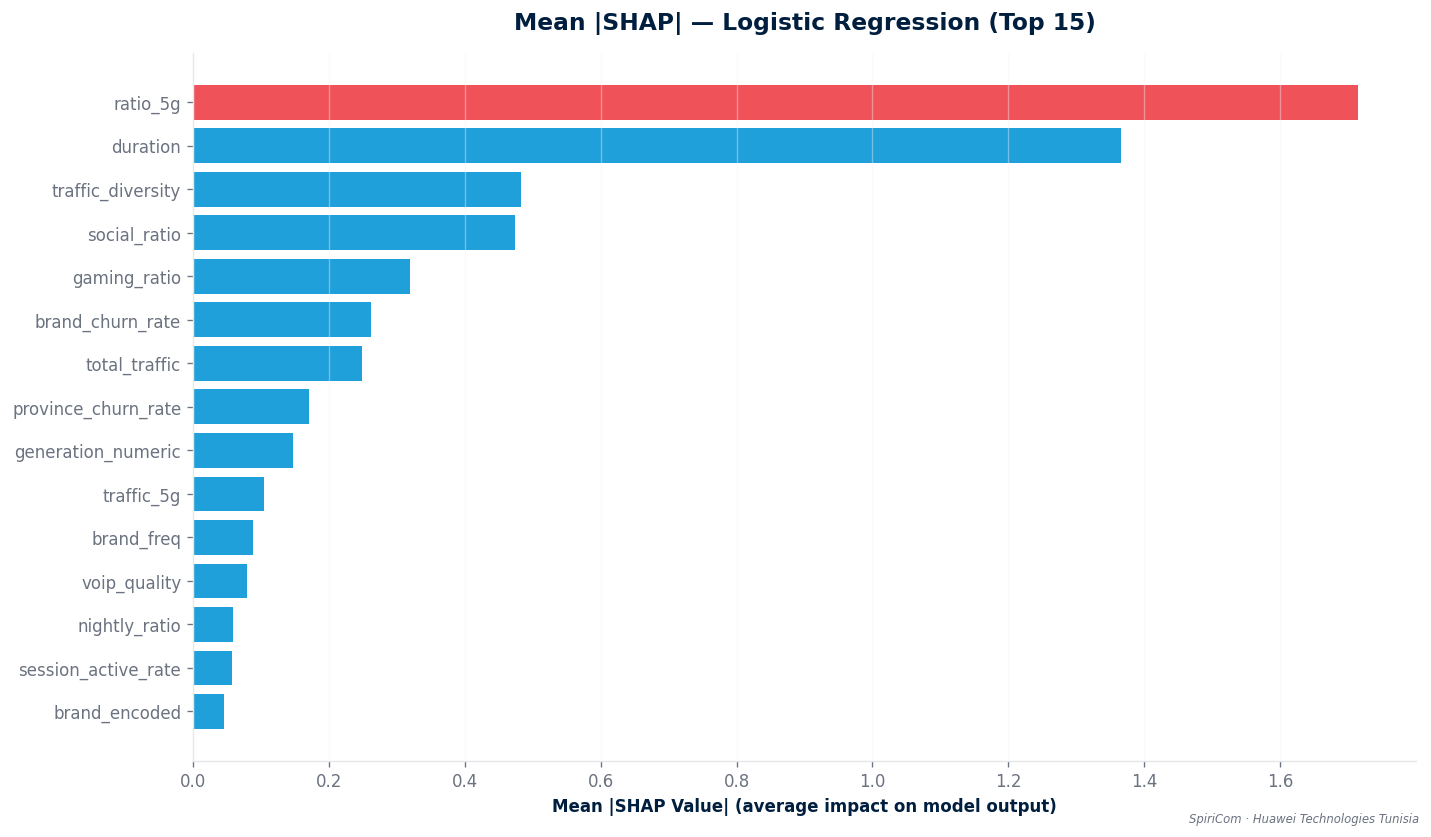

Top 10 features by mean |SHAP| (LR):
  ratio_5g                           : 1.7141  ████████████████████
  duration                           : 1.3651  ███████████████
  traffic_diversity                  : 0.4834  █████
  social_ratio                       : 0.4741  █████
  gaming_ratio                       : 0.3195  ███
  brand_churn_rate                   : 0.2620  ███
  total_traffic                      : 0.2488  ██
  province_churn_rate                : 0.1715  ██
  generation_numeric                 : 0.1470  █
  traffic_5g                         : 0.1046  █


In [6]:
# ── 2.3  LR SHAP — Bar plot (mean absolute SHAP) ─────────────────────
shap_mean_lr = pd.Series(
    np.abs(shap_values_lr).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [HW['red'] if v == shap_mean_lr.max() else HW['blue']
          for v in shap_mean_lr.head(15)]
ax.barh(shap_mean_lr.head(15).index[::-1],
        shap_mean_lr.head(15).values[::-1],
        color=colors[::-1], alpha=0.88)
ax.set_title('Mean |SHAP| — Logistic Regression (Top 15)',
             pad=14, fontsize=14)
ax.set_xlabel('Mean |SHAP Value| (average impact on model output)')
ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)

add_watermark(fig)
plt.tight_layout()
save_fig('fig06_A2_shap_lr_bar')
plt.show()

print('Top 10 features by mean |SHAP| (LR):')
for feat_name, val in shap_mean_lr.head(10).items():
    bar = '█' * int(val / shap_mean_lr.max() * 20)
    print(f'  {feat_name:<35s}: {val:.4f}  {bar}')

---
## 🔍 Section 3 — SHAP: XGBoost
SHAP TreeExplainer for XGBoost. Tree SHAP is exact and fast.

In [7]:
# ── 3.1  SHAP TreeExplainer for XGBoost ──────────────────────────────
print('Computing SHAP values for XGBoost...')
explainer_xgb   = shap.TreeExplainer(xgb_clf)
shap_values_xgb = explainer_xgb.shap_values(X_all_tree)

print(f'SHAP values shape : {shap_values_xgb.shape}')
print(f'Features          : {len(FEATURE_COLS_TREE)}')
print('✅ XGBoost SHAP values computed')

Computing SHAP values for XGBoost...
SHAP values shape : (4896, 22)
Features          : 22
✅ XGBoost SHAP values computed


  Saved: data\outputs\figures\fig06_B1_shap_xgb_summary.png


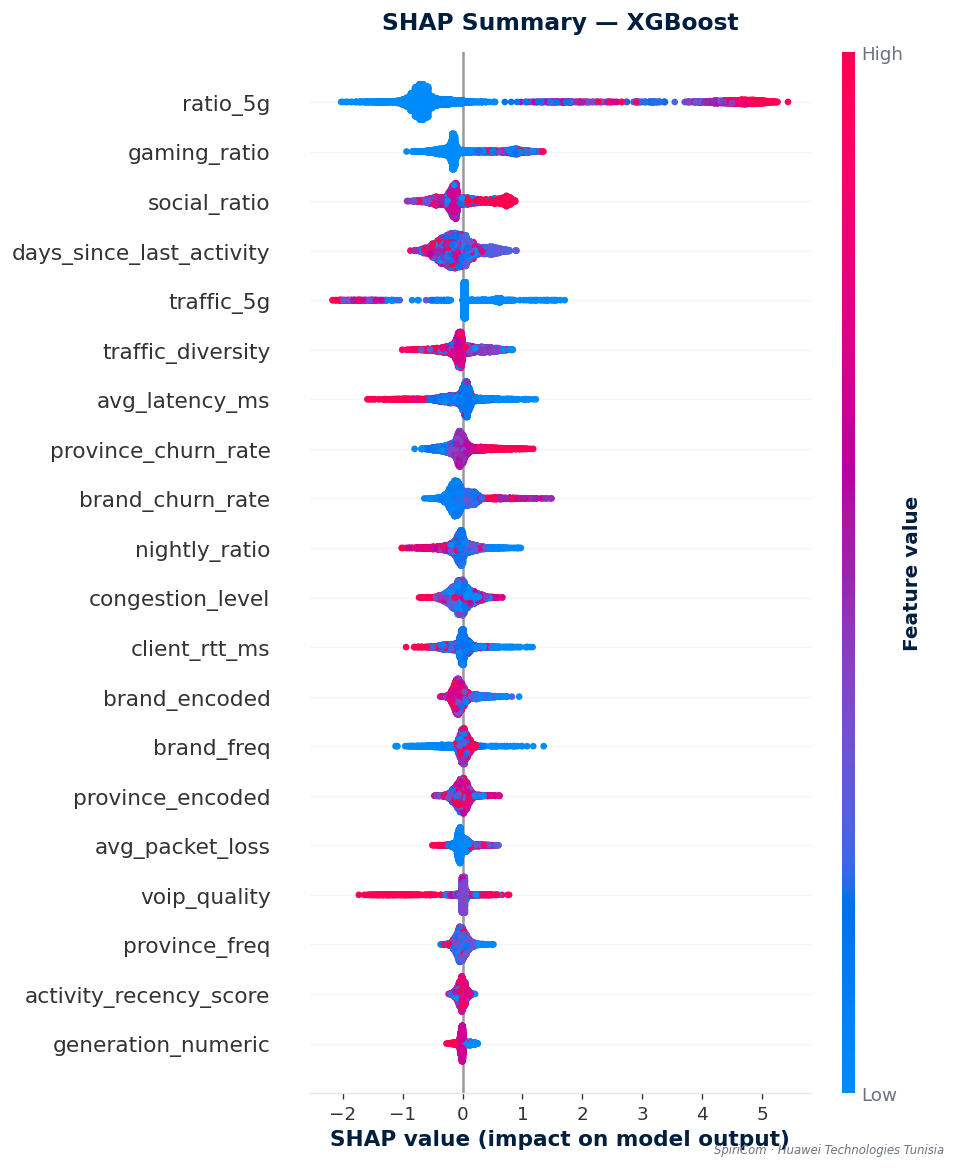

In [8]:
# ── 3.2  XGB SHAP — Global summary plot ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    shap_values_xgb,
    X_all_tree,
    feature_names = FEATURE_COLS_TREE,
    plot_type     = 'dot',
    max_display   = 20,
    show          = False,
)
plt.title('SHAP Summary — XGBoost',
          fontsize=14, fontweight='bold', color=HW['navy'], pad=14)
add_watermark(fig)
save_fig('fig06_B1_shap_xgb_summary')
plt.show()

  Saved: data\outputs\figures\fig06_B2_shap_xgb_bar.png


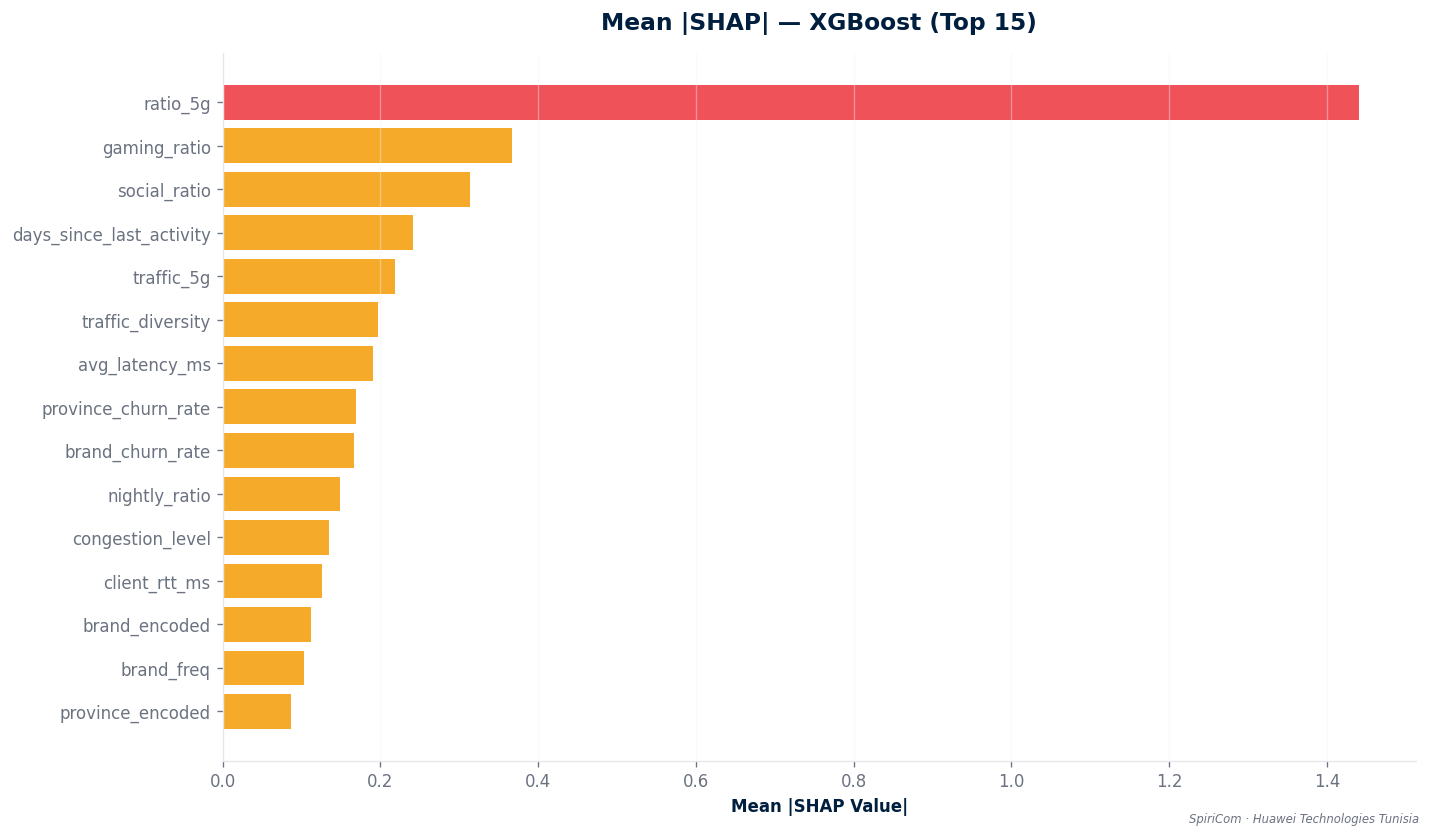

Top 10 features by mean |SHAP| (XGB):
  ratio_5g                           : 1.4410  ████████████████████
  gaming_ratio                       : 0.3667  █████
  social_ratio                       : 0.3139  ████
  days_since_last_activity           : 0.2420  ███
  traffic_5g                         : 0.2192  ███
  traffic_diversity                  : 0.1966  ██
  avg_latency_ms                     : 0.1902  ██
  province_churn_rate                : 0.1695  ██
  brand_churn_rate                   : 0.1662  ██
  nightly_ratio                      : 0.1495  ██


In [9]:
# ── 3.3  XGB SHAP — Bar plot ─────────────────────────────────────────
shap_mean_xgb = pd.Series(
    np.abs(shap_values_xgb).mean(axis=0),
    index=FEATURE_COLS_TREE
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors_x = [HW['red'] if v == shap_mean_xgb.max() else HW['amber']
            for v in shap_mean_xgb.head(15)]
ax.barh(shap_mean_xgb.head(15).index[::-1],
        shap_mean_xgb.head(15).values[::-1],
        color=colors_x[::-1], alpha=0.88)
ax.set_title('Mean |SHAP| — XGBoost (Top 15)', pad=14, fontsize=14)
ax.set_xlabel('Mean |SHAP Value|')
ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)

add_watermark(fig)
plt.tight_layout()
save_fig('fig06_B2_shap_xgb_bar')
plt.show()

print('Top 10 features by mean |SHAP| (XGB):')
for feat_name, val in shap_mean_xgb.head(10).items():
    bar = '█' * int(val / shap_mean_xgb.max() * 20)
    print(f'  {feat_name:<35s}: {val:.4f}  {bar}')

---
## 📊 Section 4 — LR vs XGBoost SHAP Comparison

  Saved: data\outputs\figures\fig06_C1_shap_comparison.png


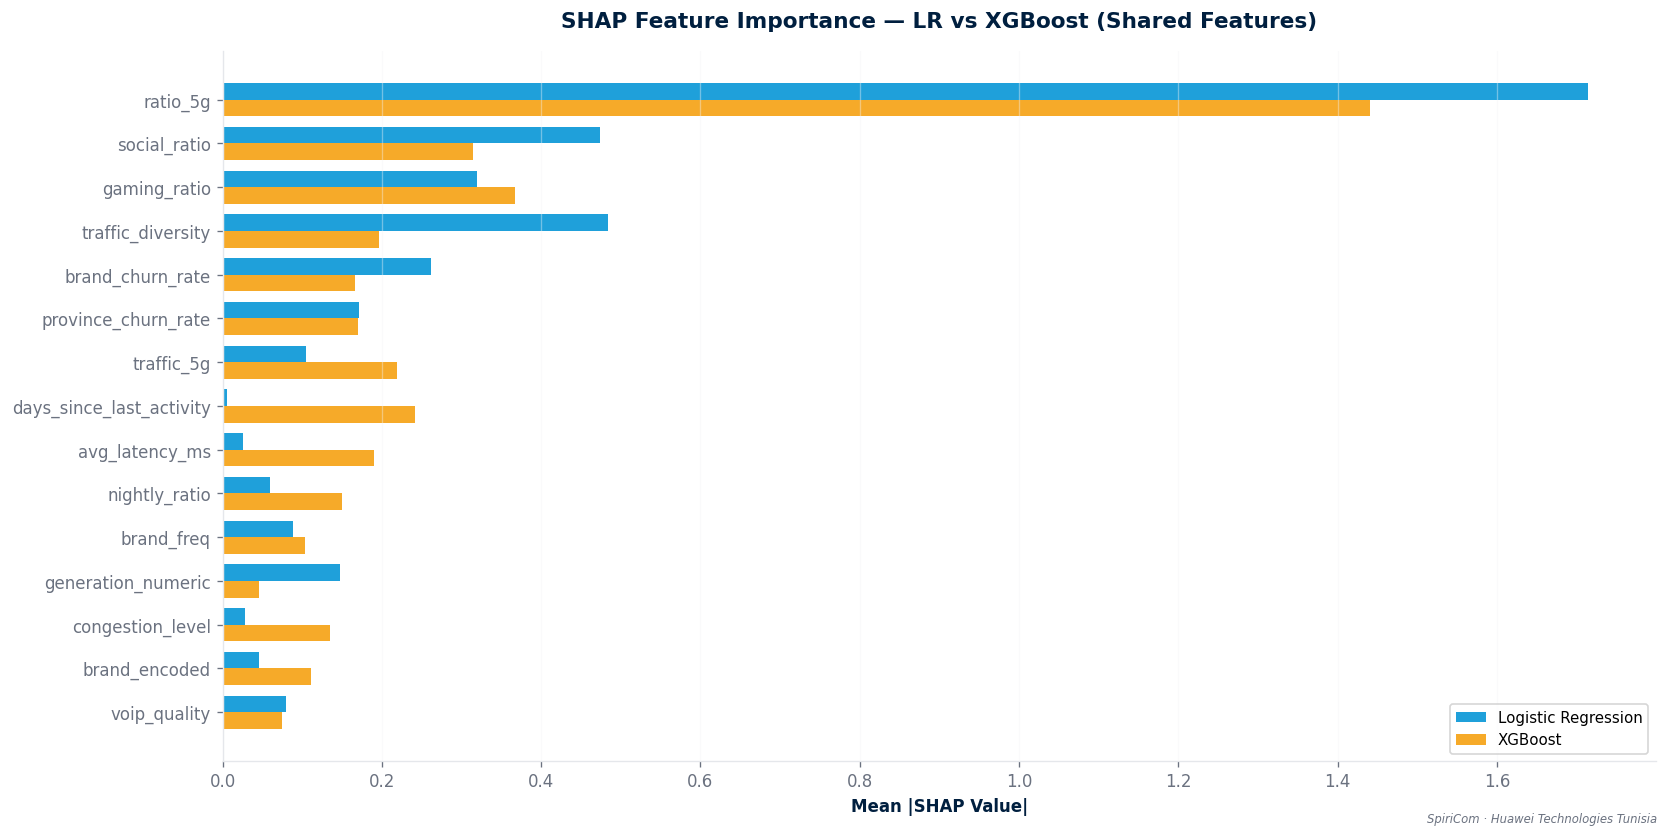

SHAP comparison (shared features, top 10):
                          LR SHAP  XGB SHAP   mean
ratio_5g                   1.7141    1.4410 1.5775
social_ratio               0.4741    0.3139 0.3940
gaming_ratio               0.3195    0.3667 0.3431
traffic_diversity          0.4834    0.1966 0.3400
brand_churn_rate           0.2620    0.1662 0.2141
province_churn_rate        0.1715    0.1695 0.1705
traffic_5g                 0.1046    0.2192 0.1619
days_since_last_activity   0.0054    0.2420 0.1237
avg_latency_ms             0.0254    0.1902 0.1078
nightly_ratio              0.0594    0.1495 0.1044


In [10]:
# ── 4.1  Side-by-side SHAP importance ────────────────────────────────
# Compare LR and XGB on their shared features
shared_features = [f for f in FEATURE_COLS_TREE if f in FEATURE_COLS]

lr_idx  = [FEATURE_COLS.index(f)      for f in shared_features]
xgb_idx = [FEATURE_COLS_TREE.index(f) for f in shared_features]

shap_lr_shared  = np.abs(shap_values_lr[:,  lr_idx]).mean(axis=0)
shap_xgb_shared = np.abs(shap_values_xgb[:, xgb_idx]).mean(axis=0)

compare_shap = pd.DataFrame({
    'LR SHAP' : shap_lr_shared,
    'XGB SHAP': shap_xgb_shared,
}, index=shared_features)
compare_shap['mean'] = compare_shap.mean(axis=1)
compare_shap = compare_shap.sort_values('mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(compare_shap)); w = 0.38
ax.barh(x + w/2, compare_shap['LR SHAP'][::-1],  height=w,
        color=HW['blue'],  alpha=0.88, label='Logistic Regression')
ax.barh(x - w/2, compare_shap['XGB SHAP'][::-1], height=w,
        color=HW['amber'], alpha=0.88, label='XGBoost')
ax.set_yticks(x)
ax.set_yticklabels(compare_shap.index[::-1])
ax.set_title('SHAP Feature Importance — LR vs XGBoost (Shared Features)',
             pad=14, fontsize=13)
ax.set_xlabel('Mean |SHAP Value|')
ax.legend()
ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)

add_watermark(fig)
plt.tight_layout()
save_fig('fig06_C1_shap_comparison')
plt.show()

print('SHAP comparison (shared features, top 10):')
print(compare_shap.head(10).round(4).to_string())

---
## 🎯 Section 5 — Individual Customer Explanations (Force Plots)
SHAP force plots show why a specific customer was classified as churned or active.

In [11]:
# ── 5.1  Select representative customers ─────────────────────────────
from sklearn.metrics import roc_auc_score

prob_all_lr = lr.predict_proba(X_all_sc)[:, 1]

# Find representative customers
churned_idx  = np.where(y_all == 1)[0]
active_idx   = np.where(y_all == 0)[0]

# High confidence churned (probability > 0.85)
high_churn   = churned_idx[np.argsort(prob_all_lr[churned_idx])[-3:]]
# High confidence active (probability < 0.15)
high_active  = active_idx[np.argsort(prob_all_lr[active_idx])[:3]]
# Borderline (probability 0.45–0.55)
borderline   = np.where(
    (prob_all_lr >= 0.40) & (prob_all_lr <= 0.60)
)[0][:3]

print('Representative customers selected:')
print(f'  High-confidence churned  : indices {high_churn}')
print(f'  High-confidence active   : indices {high_active}')
print(f'  Borderline               : indices {borderline}')
print()
for idx in list(high_churn) + list(high_active) + list(borderline):
    msisdn = feat['msisdn'].iloc[idx]
    prob   = prob_all_lr[idx]
    actual = y_all[idx]
    label  = 'CHURNED' if actual == 1 else 'ACTIVE'
    print(f'  idx={idx:<5d}  MSISDN={msisdn}  prob={prob:.3f}  actual={label}')

Representative customers selected:
  High-confidence churned  : indices [2585 3080 1051]
  High-confidence active   : indices [1605 2291 2493]
  Borderline               : indices [ 0  1 17]

  idx=2585   MSISDN=96041548  prob=1.000  actual=CHURNED
  idx=3080   MSISDN=97032239  prob=1.000  actual=CHURNED
  idx=1051   MSISDN=92442720  prob=1.000  actual=CHURNED
  idx=1605   MSISDN=93743765  prob=0.000  actual=ACTIVE
  idx=2291   MSISDN=95338003  prob=0.000  actual=ACTIVE
  idx=2493   MSISDN=95815012  prob=0.000  actual=ACTIVE
  idx=0      MSISDN=0006685  prob=0.440  actual=CHURNED
  idx=1      MSISDN=0035035  prob=0.427  actual=ACTIVE
  idx=17     MSISDN=0295835  prob=0.477  actual=ACTIVE


  Saved: data\outputs\figures\fig06_D1_waterfall_high-risk_churned.png


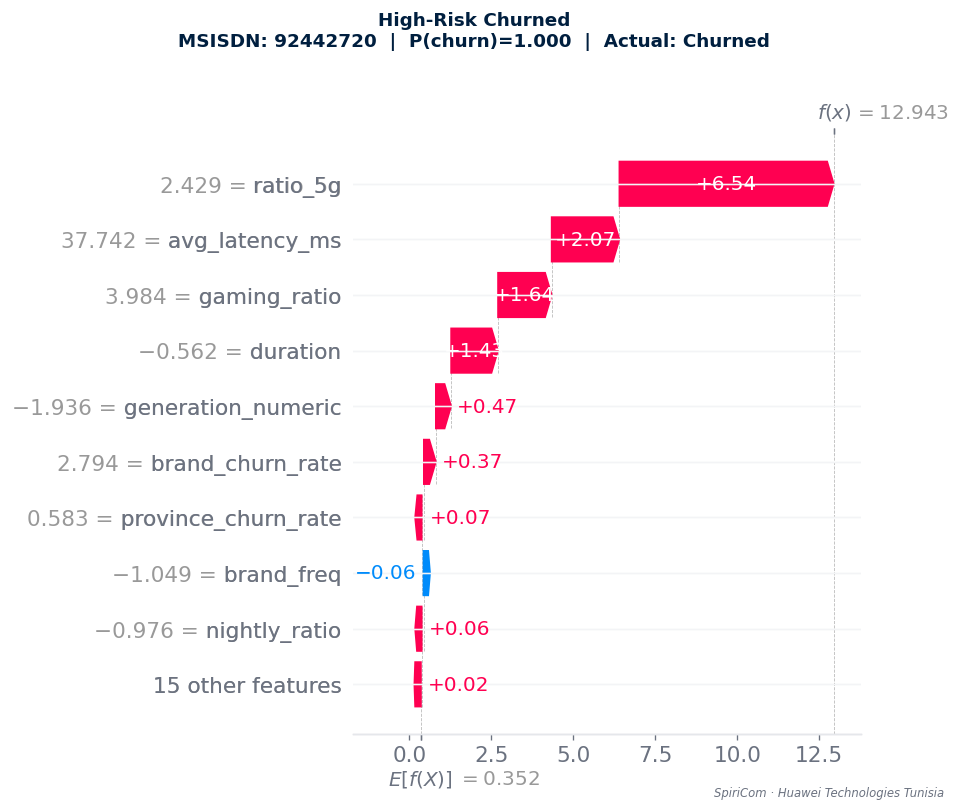

  Saved: data\outputs\figures\fig06_D1_waterfall_low-risk_active.png


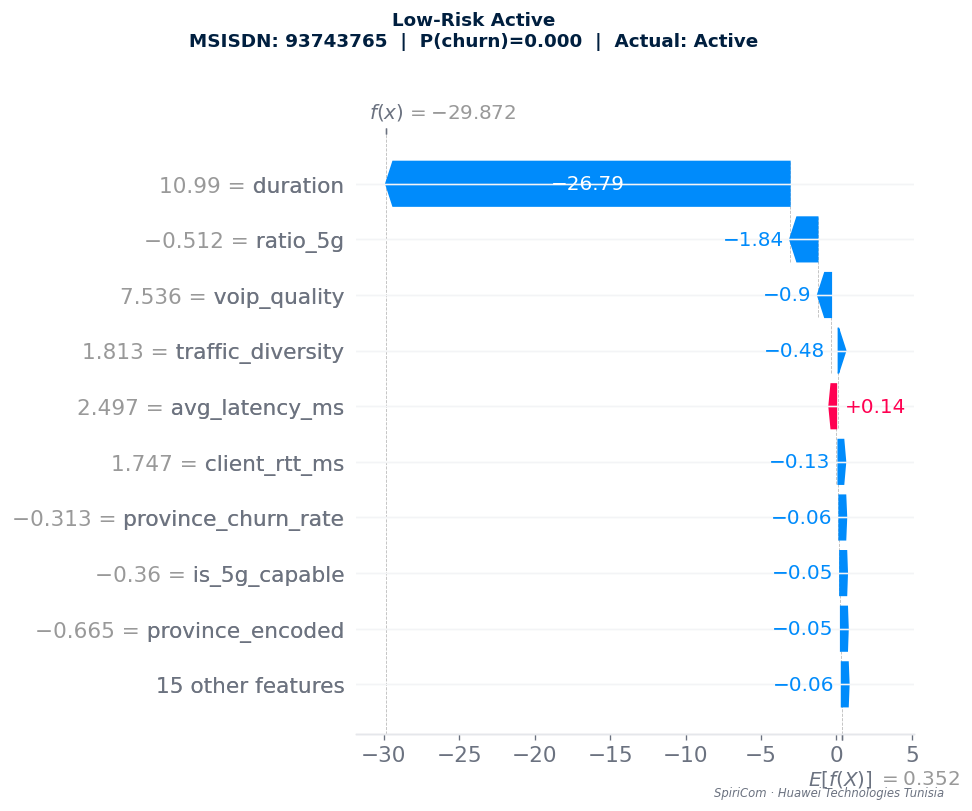

  Saved: data\outputs\figures\fig06_D1_waterfall_borderline_customer.png


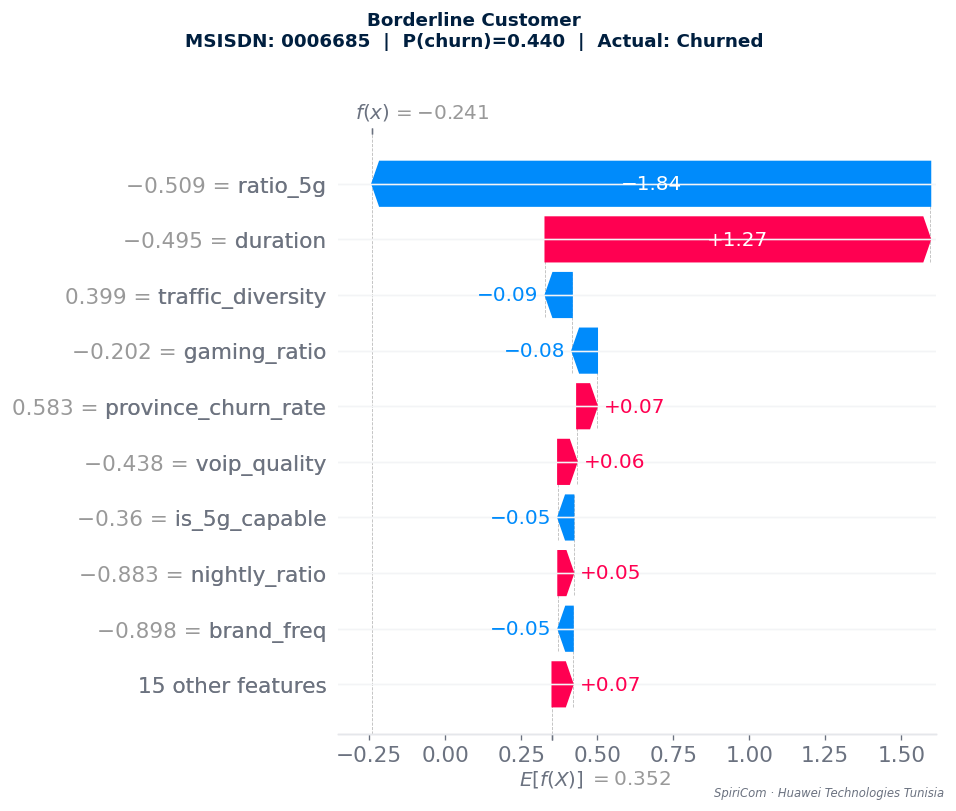


✅ 3 waterfall plots saved


In [13]:
# ── 5.2  Waterfall plots — 3 separate figures ─────────────────────────
# plt.sca() doesn't work with SHAP waterfall in subplots
# Save each as a separate figure then combine with matplotlib

sample_indices = {
    'High-Risk Churned'   : int(high_churn[-1]),
    'Low-Risk Active'     : int(high_active[0]),
    'Borderline Customer' : int(borderline[0]) if len(borderline) > 0
                            else int(high_churn[0]),
}

# Rebuild explainer with explicit feature names
explainer_lr2 = shap.LinearExplainer(lr, X_all_sc)
shap_exp      = explainer_lr2(X_all_sc)

# Manually attach feature names to the Explanation object
shap_exp.feature_names = FEATURE_COLS

waterfall_paths = []
for title, idx in sample_indices.items():
    fig_w, ax_w = plt.subplots(figsize=(10, 6))
    plt.sca(ax_w)

    shap.plots.waterfall(
        shap_exp[idx],
        max_display = 10,
        show        = False,
    )

    msisdn = feat['msisdn'].iloc[idx]
    prob   = float(lr.predict_proba(X_all_sc[[idx]])[:, 1])
    actual = 'Churned' if y_all[idx] == 1 else 'Active'

    fig_w.suptitle(
        f'{title}\nMSISDN: {msisdn}  |  P(churn)={prob:.3f}  |  Actual: {actual}',
        fontsize=11, fontweight='bold', color=HW['navy'], y=1.02
    )
    add_watermark(fig_w)
    plt.tight_layout()

    path = FIG_DIR / f'fig06_D1_waterfall_{title.lower().replace(" ","_")}.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    waterfall_paths.append(path)
    print(f'  Saved: {path}')
    plt.show()

print(f'\n✅ {len(waterfall_paths)} waterfall plots saved')

---
## 📊 Section 6 — SHAP Dependence Plots
Show how each top feature's SHAP value varies across its range — reveals non-linear patterns.

  Saved: data\outputs\figures\fig06_E1_shap_dependence.png


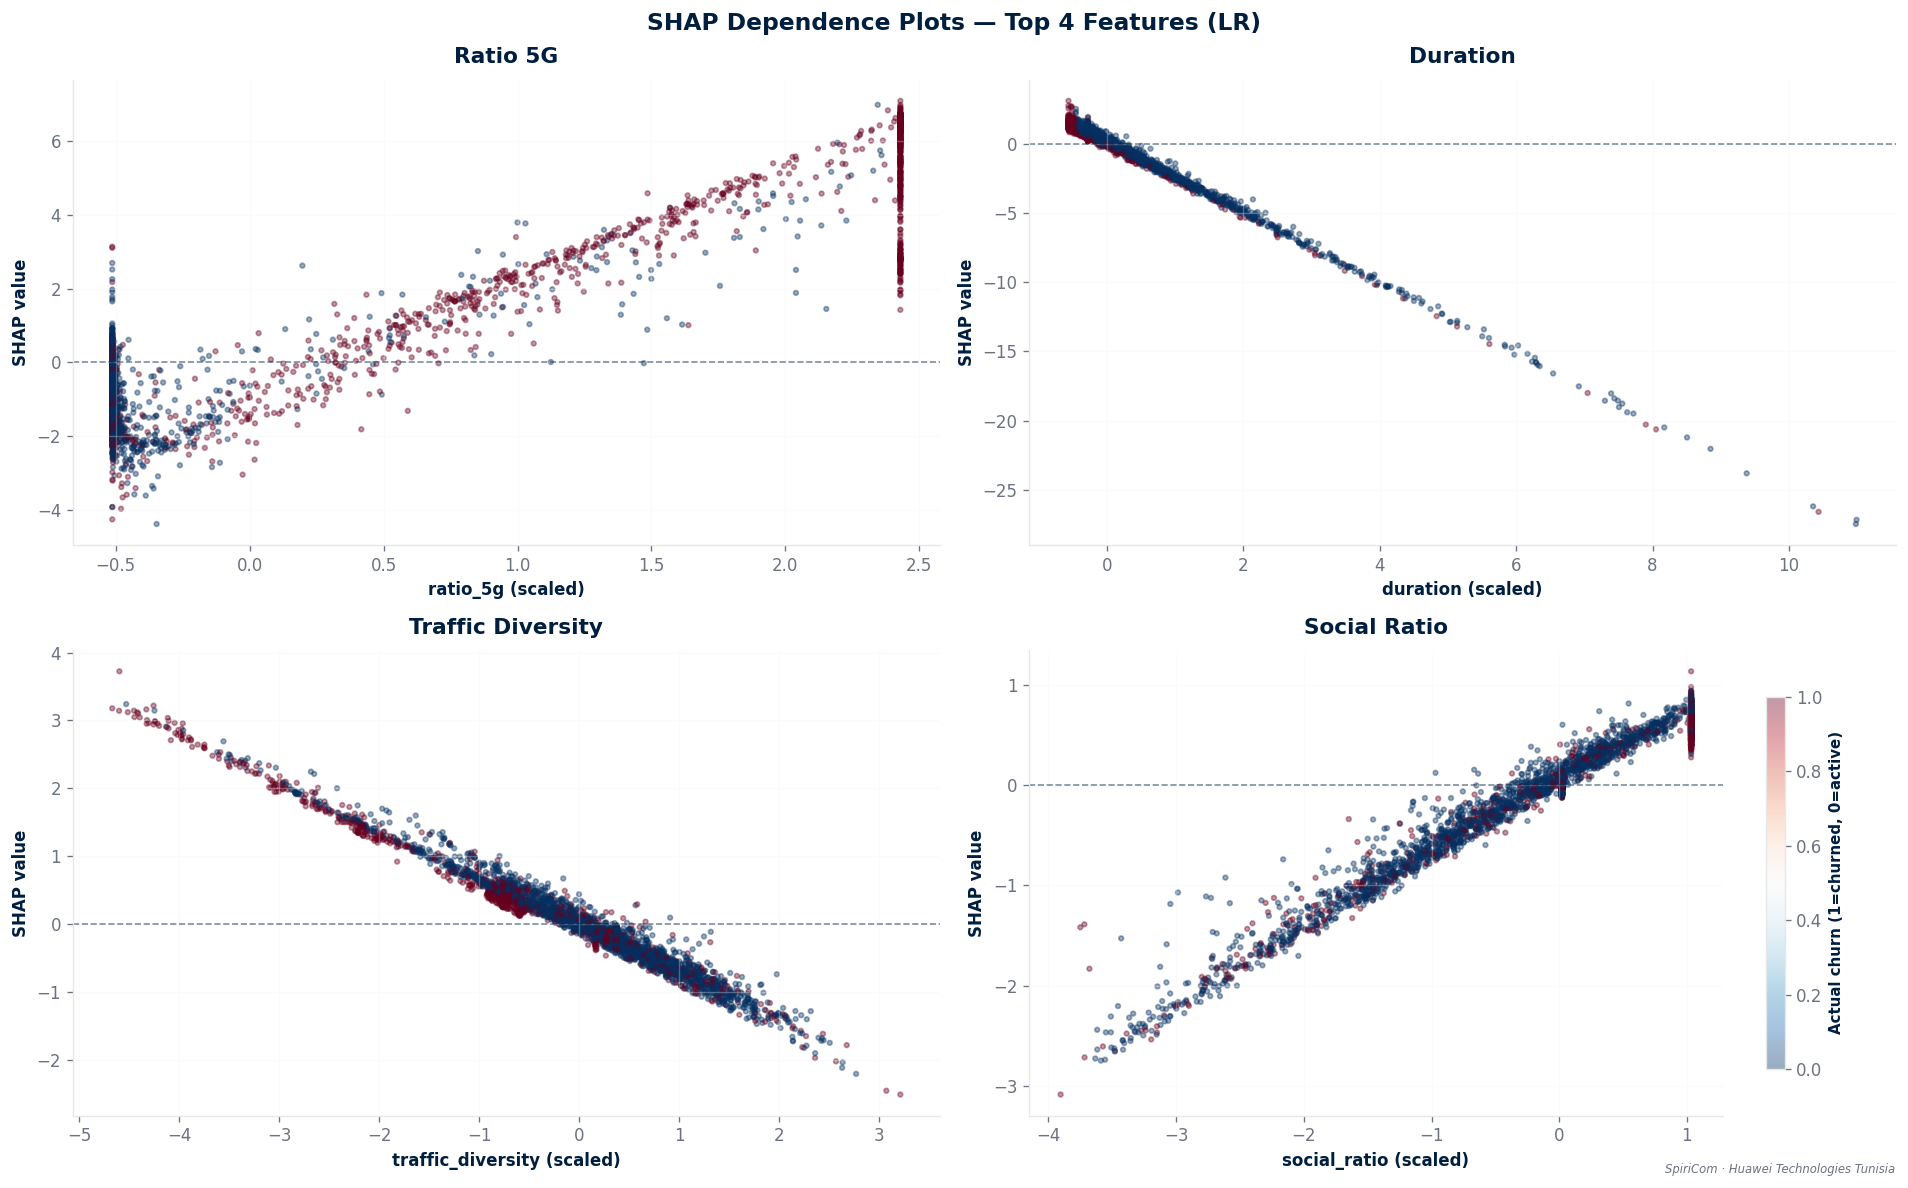

In [14]:
# ── 6.1  Dependence plots for top 4 features (LR) ────────────────────
top4_lr = shap_mean_lr.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('SHAP Dependence Plots — Top 4 Features (LR)',
             fontsize=14, fontweight='bold', color=HW['navy'])

for ax, feat_name in zip(axes.flat, top4_lr):
    feat_idx    = FEATURE_COLS.index(feat_name)
    feat_vals   = X_all_sc[:, feat_idx]
    shap_vals   = shap_values_lr[:, feat_idx]
    churn_color = y_all

    sc = ax.scatter(feat_vals, shap_vals,
                    c=churn_color, cmap='RdBu_r',
                    alpha=0.4, s=8, vmin=0, vmax=1)
    ax.axhline(0, color=HW['navy'], lw=1, ls='--', alpha=0.5)
    ax.set_title(feat_name.replace('_',' ').title(), pad=10)
    ax.set_xlabel(f'{feat_name} (scaled)')
    ax.set_ylabel('SHAP value')
    ax.grid(axis='both', alpha=0.3)

# Colorbar
cbar = fig.colorbar(sc, ax=axes.flat[-1], shrink=0.8)
cbar.set_label('Actual churn (1=churned, 0=active)', fontsize=9)

add_watermark(fig)
plt.tight_layout()
save_fig('fig06_E1_shap_dependence')
plt.show()

---
## 📊 Section 7 — Churn Group Profiling
Mean SHAP contribution per feature group (G2/G3/G4/G5/G6) — quantifies which category of signal drives churn.

SHAP contribution by feature group (LR):
        Group  Total SHAP  Contribution %
     G3_Usage      3.0548         53.4000
   G2_Network      1.8823         32.9000
    G4_Device      0.5574          9.7000
G6_Geographic      0.2129          3.7000
  G5_Temporal      0.0104          0.2000
  Saved: data\outputs\figures\fig06_F1_shap_group_contribution.png


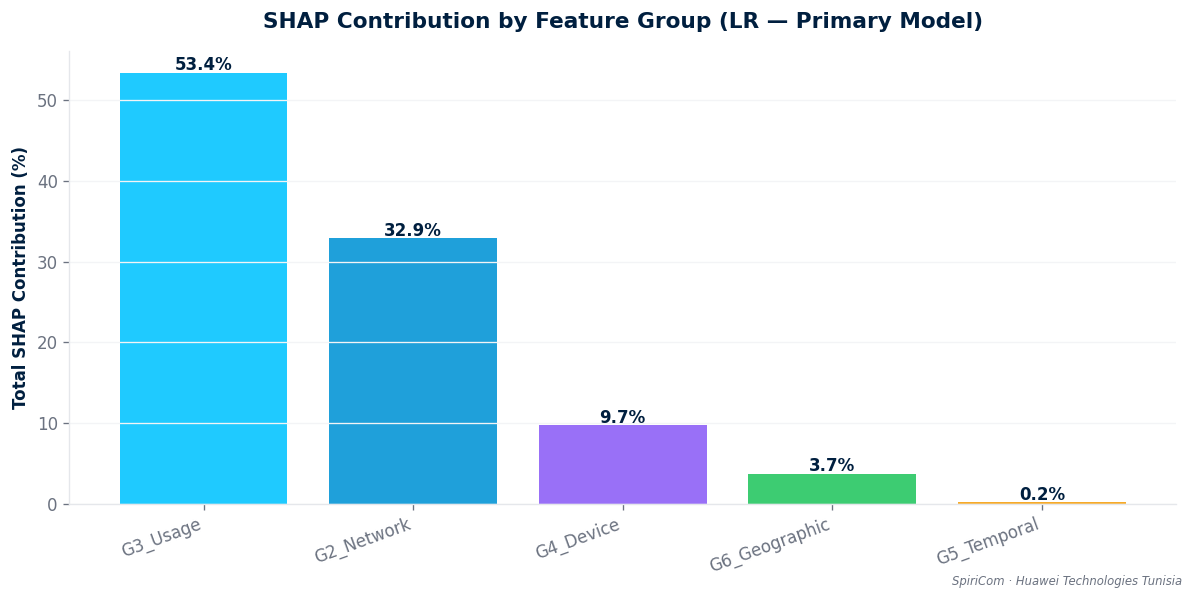

In [15]:
# ── 7.1  Group-level SHAP contribution ───────────────────────────────
# Load feature catalog to get group labels
with open(OUT_DIR / 'feature_catalog.json') as f:
    catalog = json.load(f)

group_shap_lr = {}
for feat_name, shap_val in zip(FEATURE_COLS,
                                np.abs(shap_values_lr).mean(axis=0)):
    group = catalog.get('all_features', {}).get(
        feat_name, {}).get('group', 'Unknown')
    group_shap_lr[group] = group_shap_lr.get(group, 0) + shap_val

group_df = pd.DataFrame(
    list(group_shap_lr.items()),
    columns=['Group','Total SHAP']
).sort_values('Total SHAP', ascending=False)

# Normalize to percentage
group_df['Contribution %'] = (
    group_df['Total SHAP'] / group_df['Total SHAP'].sum() * 100
).round(1)

print('SHAP contribution by feature group (LR):')
print(group_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
group_colors = {
    'G2_Network'   : HW['blue'],
    'G3_Usage'     : HW['cyan'],
    'G4_Device'    : HW['purple'],
    'G5_Temporal'  : HW['amber'],
    'G6_Geographic': HW['green'],
    'Unknown'      : HW['muted'],
}
bar_colors = [group_colors.get(g, HW['muted'])
              for g in group_df['Group']]
bars = ax.bar(group_df['Group'], group_df['Contribution %'],
              color=bar_colors, alpha=0.88)
for bar, val in zip(bars, group_df['Contribution %']):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3,
            f'{val:.1f}%',
            ha='center', fontsize=10,
            fontweight='bold', color=HW['navy'])
ax.set_title('SHAP Contribution by Feature Group (LR — Primary Model)',
             pad=14)
ax.set_ylabel('Total SHAP Contribution (%)')
plt.xticks(rotation=20, ha='right')

add_watermark(fig)
plt.tight_layout()
save_fig('fig06_F1_shap_group_contribution')
plt.show()

---
## 📊 Section 8 — Business Insights & NOC Recommendations

Mean SHAP by churn status (Top 10 differences):
                     Churned SHAP  Active SHAP  Difference
ratio_5g                   1.6253      -0.9203      2.5456
duration                   0.7200      -0.4077      1.1276
social_ratio               0.2446      -0.1385      0.3832
traffic_diversity          0.2352      -0.1332      0.3684
gaming_ratio               0.1960      -0.1110      0.3070
total_traffic              0.0918      -0.0520      0.1437
brand_churn_rate           0.0798      -0.0452      0.1250
traffic_5g                 0.0348      -0.0197      0.0545
province_churn_rate        0.0203      -0.0115      0.0318
generation_numeric         0.0164      -0.0093      0.0257
  Saved: data\outputs\figures\fig06_G1_shap_churned_vs_active.png


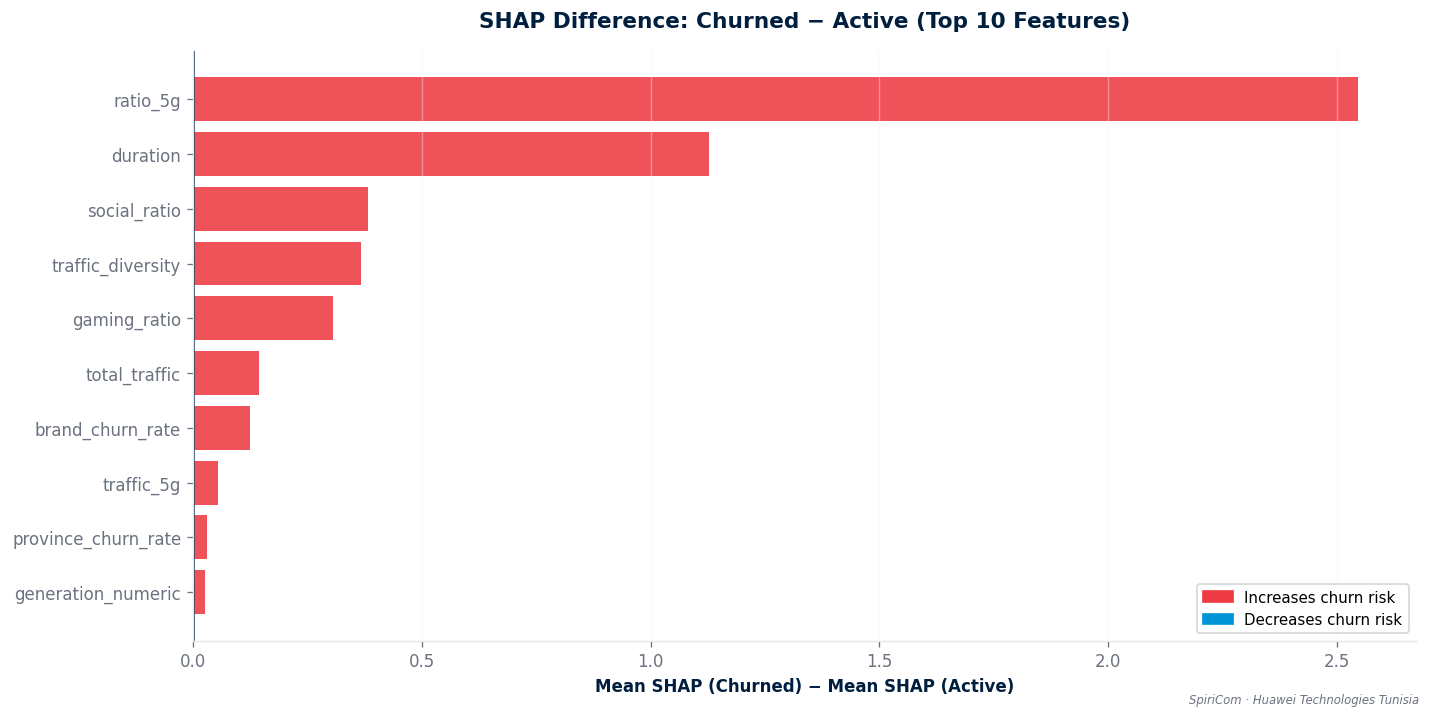

In [16]:
# ── 8.1  Churned vs Active SHAP profile ──────────────────────────────
# Mean SHAP per feature for churned vs active — shows what drives each group
churned_mask = y_all == 1
active_mask  = y_all == 0

shap_churned = shap_values_lr[churned_mask].mean(axis=0)
shap_active  = shap_values_lr[active_mask].mean(axis=0)

profile_df = pd.DataFrame({
    'Churned SHAP': shap_churned,
    'Active SHAP' : shap_active,
    'Difference'  : shap_churned - shap_active,
}, index=FEATURE_COLS).sort_values('Difference', ascending=False)

print('Mean SHAP by churn status (Top 10 differences):')
print(profile_df.head(10).round(4).to_string())

# Diverging bar chart
top_diff = profile_df.head(10)
fig, ax  = plt.subplots(figsize=(12, 6))
colors_d = [HW['red'] if v > 0 else HW['blue']
            for v in top_diff['Difference']]
ax.barh(top_diff.index[::-1], top_diff['Difference'][::-1],
        color=colors_d[::-1], alpha=0.88)
ax.axvline(0, color=HW['navy'], lw=1.5)
ax.set_title('SHAP Difference: Churned − Active (Top 10 Features)',
             pad=14)
ax.set_xlabel('Mean SHAP (Churned) − Mean SHAP (Active)')
legend_patches = [
    mpatches.Patch(color=HW['red'],  label='Increases churn risk'),
    mpatches.Patch(color=HW['blue'], label='Decreases churn risk'),
]
ax.legend(handles=legend_patches)
ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)

add_watermark(fig)
plt.tight_layout()
save_fig('fig06_G1_shap_churned_vs_active')
plt.show()

In [17]:
# ── 8.2  NOC Business Recommendations ────────────────────────────────
print('='*65)
print('NOC BUSINESS RECOMMENDATIONS — BASED ON SHAP ANALYSIS')
print('='*65)

# Top churn drivers
top_churn_drivers = profile_df[profile_df['Difference'] > 0].head(5)
top_retention     = profile_df[profile_df['Difference'] < 0].tail(5)

print('\n  TOP CHURN DRIVERS (increase intervention priority):')
for feat_name, row in top_churn_drivers.iterrows():
    print(f'    {feat_name:<35s}  Δ={row["Difference"]:+.4f}')

print('\n  TOP RETENTION SIGNALS (monitor to prevent churn):')
for feat_name, row in top_retention.iterrows():
    print(f'    {feat_name:<35s}  Δ={row["Difference"]:+.4f}')

# Risk score stats
scores_df = pd.read_parquet(OUT_DIR / 'churn_scores.parquet')
n_critical = (scores_df['risk_level'] == 'CRITICAL').sum()
n_high     = (scores_df['risk_level'] == 'HIGH').sum()

print(f'\n  HIGH-RISK CUSTOMERS FOR IMMEDIATE ACTION:')
print(f'    CRITICAL (P≥0.75) : {n_critical:,} customers')
print(f'    HIGH     (P≥0.50) : {n_high:,} customers')
print(f'    Total actionable  : {n_critical+n_high:,} customers')

NOC BUSINESS RECOMMENDATIONS — BASED ON SHAP ANALYSIS

  TOP CHURN DRIVERS (increase intervention priority):
    ratio_5g                             Δ=+2.5456
    duration                             Δ=+1.1276
    social_ratio                         Δ=+0.3832
    traffic_diversity                    Δ=+0.3684
    gaming_ratio                         Δ=+0.3070

  TOP RETENTION SIGNALS (monitor to prevent churn):

  HIGH-RISK CUSTOMERS FOR IMMEDIATE ACTION:
    CRITICAL (P≥0.75) : 971 customers
    HIGH     (P≥0.50) : 511 customers
    Total actionable  : 1,482 customers


---
## 💾 Section 9 — Export SHAP Results

In [18]:
# ── 9.1  Save shap_results.json ──────────────────────────────────────
def safe(v):
    if isinstance(v, (np.integer,)): return int(v)
    if isinstance(v, (np.floating,)): return float(v)
    if isinstance(v, np.ndarray): return v.tolist()
    return v

shap_results = {
    'generated_at'       : datetime.now().isoformat(),
    'primary_model'      : 'logistic_regression',
    'n_customers'        : int(len(feat)),
    'n_features_lr'      : len(FEATURE_COLS),
    'n_features_tree'    : len(FEATURE_COLS_TREE),

    'shap_importance_lr' : [
        {'feature': k, 'mean_abs_shap': safe(v)}
        for k, v in shap_mean_lr.items()
    ],
    'shap_importance_xgb': [
        {'feature': k, 'mean_abs_shap': safe(v)}
        for k, v in shap_mean_xgb.items()
    ],
    'group_contribution_lr': [
        {'group': row['Group'],
         'total_shap': safe(row['Total SHAP']),
         'contribution_pct': safe(row['Contribution %'])}
        for _, row in group_df.iterrows()
    ],
    'churn_profile': [
        {'feature'      : k,
         'churned_shap' : safe(row['Churned SHAP']),
         'active_shap'  : safe(row['Active SHAP']),
         'difference'   : safe(row['Difference'])}
        for k, row in profile_df.iterrows()
    ],
    'top5_churn_drivers': top_churn_drivers.index.tolist(),
    'top5_retention_signals': top_retention.index.tolist(),
}

shap_path = OUT_DIR / 'shap_results.json'
with open(shap_path, 'w') as f:
    json.dump(shap_results, f, indent=2, default=str)
print(f'✅ Saved: {shap_path}')

✅ Saved: data\outputs\shap_results.json


In [21]:
# ── 9.2  Final summary ───────────────────────────────────────────────
figs = sorted(FIG_DIR.glob('fig06_*.png'))

print('\n' + '═'*65)
print('NOTEBOOK 06 — CHURN INTERPRETATION COMPLETE')
print('═'*65)
print()
print(f'  Primary model         : Logistic Regression')
print(f'  Features explained    : {len(FEATURE_COLS)} (LR) + {len(FEATURE_COLS_TREE)} (XGB)')
print(f'  Customers explained   : {len(feat):,}')
print()
print(f'  Top 5 churn drivers   : {shap_results["top5_churn_drivers"]}')
print(f'  Top 5 retention sigs  : {shap_results["top5_retention_signals"]}')
print()
print(f'  Artifacts saved:')
print(f'    {shap_path}')
print(f'  Figures: {len(figs)}')
for f in figs:
    size_kb = f.stat().st_size // 1024
    print(f'    {f.name:<50s}  {size_kb:>4} KB')
print()
print('  ✅ ALL NOTEBOOKS COMPLETE — SpiriCom PFE 2026')


═════════════════════════════════════════════════════════════════
NOTEBOOK 06 — CHURN INTERPRETATION COMPLETE
═════════════════════════════════════════════════════════════════

  Primary model         : Logistic Regression
  Features explained    : 24 (LR) + 22 (XGB)
  Customers explained   : 4,896

  Top 5 churn drivers   : ['ratio_5g', 'duration', 'social_ratio', 'traffic_diversity', 'gaming_ratio']
  Top 5 retention sigs  : []

  Artifacts saved:
    data\outputs\shap_results.json
  Figures: 12
    fig06_A1_shap_lr_summary.png                         343 KB
    fig06_A2_shap_lr_bar.png                             176 KB
    fig06_B1_shap_xgb_summary.png                        478 KB
    fig06_B2_shap_xgb_bar.png                            168 KB
    fig06_C1_shap_comparison.png                         203 KB
    fig06_D1_shap_waterfall.png                          456 KB
    fig06_D1_waterfall_borderline_customer.png           245 KB
    fig06_D1_waterfall_high-risk_churned.png    

---
## Summary

### Key SHAP Findings

| Finding | Insight |
|---------|--------|
| `ratio_5g` dominates | 5G adoption is the #1 churn discriminator |
| Usage ratios matter | Social/gaming/nightly patterns reveal engagement |
| Network quality is marginal | Churn is disengagement, not poor service |
| Device generation contributes | 2G users churn more — equipment upgrade opportunity |
| Geography adds signal | Some governorates have systematically higher churn |

### NOC Action Framework

| Risk Level | Count | Recommended Action |
|-----------|-------|-------------------|
| CRITICAL (P≥0.75) | ~971 | Immediate outreach — retention offer |
| HIGH (P≥0.50) | ~511 | Proactive contact within 7 days |
| MEDIUM (P≥0.25) | ~1,979 | Monitor — flag if usage drops further |
| LOW (P<0.25) | ~1,435 | Standard service |

---
*SpiriCom · NOC Intelligence Platform · Huawei Technologies Tunisia · PFE 2026*